# WasserstainGAN

In [1]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_wGAN_v2_2 import collate_fn, preprocess_data

from dotenv import load_dotenv

import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()


True

In [2]:
config_file = '../../Models/configs/config_v2_2.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_13-03-02_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'


# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_12-28-36_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'

# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_13-03-02_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'

# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_12-28-36_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'

# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_12-28-36_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'


# '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_12-28-36_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth'
# 

# /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_12-40-06_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_gaussian_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth
# 
validation_data_config = '../../Models/configs/config_v2_2_val.yaml'
STAGE = 'Stage II'
LATENT_DIM = 10

In [3]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    
    results = []
    real_features_list = []
    labels_list = []
    final_status_list = []
    with torch.no_grad():
    

        for features, labels, final_status in data_loader:
            real_features = features
    
            generator_input = torch.cat((real_features, noise_function), dim=1)

            fake_labels = generator(generator_input)
            labels =process_arrays(final_status, labels)
            final_status_list.append(labels.cpu().numpy())
            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.vstack(results), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results), np.vstack(final_status_list)

def process_arrays(final_status, labels):
    # Initialize the output tensor with zeros
    num_columns = torch.max(labels).item()  # Exclude the first column

    # Initialize the output tensor with ones, but only for the needed columns
    output = torch.ones(len(final_status), int(num_columns))
    
    for i in range(len(final_status)):
        if final_status[i] == 3:  # Assign 0 to values after the label index
            output[i, int(labels[i]):] = 0
        elif final_status[i] in [1, 2]:  # Assign 0.5 to values after the label index
            output[i, int(labels[i]):] = 0.5
    
    return output

def funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM):



    config = MongoExtractor.load_config(config_file)

    # Extract data configuration
    dc = config['data_config']

    # Load training data
    mongo_extractor_train = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=config_file
    )
    
    df = mongo_extractor_train.get_dataframe_os()

    # Load validation data
    mongo_extractor_val = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=validation_data_config
    )
    df_val= mongo_extractor_val.get_dataframe_os()
    df_val_original = mongo_extractor_val.get_dataframe_os()

    dc = config['data_config']
    mc = config['model_config']
    sgc = config['simplegan_config']
    mc['latent_dim'] = lantent_dim
    mc['noise_type'] = 'gaussian'
    mc['batch_size'] = 104

    df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

# ------------------------------
    # columns_to_zero = [
    #         'treatment_features.chemotherapy', 
            
    #         'treatment_features.radiation_oncology', 
    #         'treatment_features.resection',
    #         'treatment_features.neo_adjuvant',
            
    #         'treatment_features.dose',
    #         'treatment_features.chemotherapy',
                 
    #                 'treatment_features.cycle_number', 
    #                 'treatment_features.surgery',
    #                 'treatment_features.mib_of_sarcoma_1.0',

    #    'treatment_features.reason_chemotherapy_1.0',
    #    'treatment_features.reason_chemotherapy_2.0',
       

    #    'treatment_features.reason_chemotherapy_3.0', 
    #    'treatment_features.radiation_oncology', 'treatment_features.dose',
    #    'treatment_features.number_fractions', 'treatment_features.ptv_volume',
    #    'treatment_features.gtv_volume', 'treatment_features.resection',
    #    'treatment_features.neo_adjuvant',
    #    'treatment_features.surgery',

    #    'treatment_features.chemotherapy', 'treatment_features.cycle_number',]

    # columns_to_one =[
    #                 ] 

    # columns_to_value =[
    #                 ] 

    # value =2

    # df[columns_to_zero] = 0
    # df_val[columns_to_zero] = 0
    # df_val_original[columns_to_zero] = 0

    # df[columns_to_one] = 1
    # df_val[columns_to_one] = 1
    # df_val_original[columns_to_one] = 1



    # df[columns_to_value] = value
    # df_val[columns_to_value] = value
    # df_val_original[columns_to_value] = value

# --------------------------------

    dataset_train = EHRDataset(df)
    dataset_val = EHRDataset(df_val)

    collate_fn_dc = partial(collate_fn, dc=dc)
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


    exclude = list(set(dc['exclude_fields']) - set(dc['labels']) )
    df = df.drop(columns=exclude)
    df = df.drop(columns=dc['labels'])
    sgc['input_dim'] = df.shape[1] 

    # Load the generator model and optimizer

    generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

    device = torch.device('cpu')
    optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  
    generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
    torch.manual_seed(43)
    noise_function = get_noise_function(mc)
    categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
    all_features = df.columns.tolist()
    numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
    pred_labels, real_labels, features, pred_prob, final_status = inference(generator, data_loader_val, noise_function, device)

    return pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val, final_status

In [4]:
pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val, final_status = funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM)

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-13_13-03-02_epochs_1000_bs_64_lrgen_0.0005_lrdisc_0.0002_latent_10_optgen_adam_optdisc_adam_noise_gaussian_criterion_WLoss_wGAN_v1_2/checkpoints/generator_final.pth


In [5]:
def get_validation_df(pred_labels, real_labels, features, pred_prob, scaler):

       features= np.array(features)
       features_reshaped = features.reshape(-1, features.shape[-1])
       numerical_fields =['days_to_treatment', 'initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b', 'initial_diagnosis.initial_size_c', 'patient_info.age_at_admission', 'treatment_features.chemotherapy', 'treatment_features.closest_distance', 'treatment_features.complexity_number', 'treatment_features.cycle_number', 'treatment_features.dose', 'treatment_features.gtv_volume', 'treatment_features.max_dimension', 'treatment_features.neo_adjuvant', 'treatment_features.number_fractions', 'treatment_features.ptv_volume', 'treatment_features.radiation_oncology', 'treatment_features.resection', 'treatment_features.surgery']

       print(features_reshaped.shape)
     
       column_names =['initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b',
       'initial_diagnosis.initial_size_c', 'patient_info.age_at_admission',
       'treatment_features.surgery', 'treatment_features.max_dimension',
       'treatment_features.complexity_number',
       'treatment_features.chemotherapy', 'treatment_features.cycle_number',
       'treatment_features.radiation_oncology', 'treatment_features.dose',
       'treatment_features.number_fractions', 'treatment_features.ptv_volume',
       'treatment_features.gtv_volume', 'treatment_features.resection',
       'treatment_features.neo_adjuvant',
       'treatment_features.closest_distance', 'days_to_treatment',
       
       'initial_diagnosis.first_anatomic_region_code_grouping_B',
       'initial_diagnosis.first_anatomic_region_code_grouping_D',
       'initial_diagnosis.first_anatomic_region_code_grouping_S',
       'initial_diagnosis.first_diagnosis_malignant_benign_2.0',
       'initial_diagnosis.first_diagnosis_malignant_benign_3.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_0.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_1.0',
       'patient_info.gender_1.0', 'patient_info.gender_2.0',
       'treatment_features.grading_1.0', 'treatment_features.grading_2.0',
       'treatment_features.grading_3.0', 'treatment_features.grading_4.0',
       'treatment_features.mib_of_sarcoma_1.0',
       'treatment_features.mib_of_sarcoma_2.0',
       'treatment_features.mib_of_sarcoma_3.0',
       'treatment_features.mib_of_sarcoma_4.0',
       'treatment_features.mib_of_sarcoma_5.0',
       'treatment_features.mib_of_sarcoma_6.0',
       'treatment_features.mib_of_sarcoma_7.0',
       'treatment_features.mib_of_sarcoma_8.0',
       'treatment_features.mib_of_sarcoma_9.0',
       'treatment_features.mib_of_sarcoma_10.0',
       'treatment_features.mitotic_1.0', 'treatment_features.mitotic_2.0',
       'treatment_features.mitotic_3.0', 'treatment_features.necrosis_1.0',
       'treatment_features.necrosis_2.0', 'treatment_features.necrosis_3.0',
       'treatment_features.necrosis_4.0', 'treatment_features.necrosis_5.0',
       'treatment_features.necrosis_6.0', 'treatment_features.necrosis_9.0',
       'treatment_features.necrosis_10.0',
       'treatment_features.reason_chemotherapy_1.0',
       'treatment_features.reason_chemotherapy_2.0',
       'treatment_features.reason_chemotherapy_3.0',
       'treatment_features.side_1.0', 'treatment_features.side_2.0',
       'treatment_features.side_3.0', 'treatment_features.side_8.0']
      
       print(len(column_names))
       # Create DataFrame
       df_validation = pd.DataFrame(features_reshaped, columns=column_names)


       # Display the DataFrame

       df_validation[numerical_fields] = scaler.inverse_transform(df_validation[numerical_fields])
       # df_validation['real_labels'] = real_labels
       # df_validation['predicted_labels'] = pred_labels
       # df_validation[['no_disease', 'yes_disease']] = pred_prob
       
       return df_validation



In [6]:
df_validation = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)
df_validation

(104, 59)
59


,initial_diagnosis.initial_size_a,initial_diagnosis.initial_size_b,initial_diagnosis.initial_size_c,patient_info.age_at_admission,treatment_features.surgery,treatment_features.max_dimension,treatment_features.complexity_number,treatment_features.chemotherapy,treatment_features.cycle_number,treatment_features.radiation_oncology,...,treatment_features.necrosis_6.0,treatment_features.necrosis_9.0,treatment_features.necrosis_10.0,treatment_features.reason_chemotherapy_1.0,treatment_features.reason_chemotherapy_2.0,treatment_features.reason_chemotherapy_3.0,treatment_features.side_1.0,treatment_features.side_2.0,treatment_features.side_3.0,treatment_features.side_8.0
0,94.999992,53.000000,51.000000,55.000000,1.0,45.25,0.454545,1.172939,3.970414,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,NaN,NaN,NaN,79.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,NaN,NaN,NaN,83.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,49.999996,39.000000,39.000000,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,150.000000,60.000004,30.000002,48.000004,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,37.000000,35.000000,22.000002,56.000000,1.0,45.25,0.454545,1.001088,2.000000,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101,53.000000,47.000004,37.999996,17.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,17.999998,14.000000,12.000000,19.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
def calculate_largest_size(row):
    # Get the largest size in mm, then convert to cm
    max_size_mm = max(row['initial_diagnosis.initial_size_a'], row['initial_diagnosis.initial_size_b'], row['initial_diagnosis.initial_size_c'])
    max_size_cm = max_size_mm / 10  # Convert mm to cm
    return max_size_cm

# Function to determine tumor/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth size stage based on largest size in cm
def determine_size_stage(max_size_cm):
    if max_size_cm <= 5:
        return "T1"  # ≤ 5 cm
    elif max_size_cm <= 10:
        return "T2"  # > 5 cm and ≤ 10 cm
    elif max_size_cm <= 15:
        return "T3"  # > 10 cm and ≤ 15 cm
    elif max_size_cm > 15:
        return "T4"  # > 10 cm and ≤ 15 cm
    else:
        return "T0"  # > 15 cm

# Function to determine metastasis stage
def determine_metastasis_stage(row):
    return "M1" if row['initial_diagnosis.metastasis_initial_presentation_exists_original_1.0'] > 0 else "M0"

# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['treatment_features.grading_3.0'] > 0:
        return "G3"  # High grade
    elif row['treatment_features.grading_1.0'] > 0:
        return "G1"
    elif row['treatment_features.grading_2.0'] > 0:
        return "G2"  # Intermediate grade
    else:
        return "G2"
    # if False:
    #     return "G2"
    # else:
    #     return "G1"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and size_stage == "T1" and metastasis_stage == "M0":
        stage, prob = "Stage IA", 0.853  # Updated ~95% OS for Stage IA
    elif grade == "G1" and size_stage in ["T0","T2", "T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IB", 0.830  # Updated ~85% OS for Stage IB
    elif grade in ["G2", "G3"]  and size_stage in ["T0", "T1"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.79  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]  and size_stage in [ "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIA", 0.624  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]   and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIB", 0.501 # Updated ~45% OS for Stage IIIB
    else:
        stage, prob = "Unknown Stage", 0.0  # Default for unclassified stages
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff

# Calculate largest size in cm for each row, determine staging, probability, and difference
df_validation['max_size_cm'] = df_validation.apply(calculate_largest_size, axis=1)
df_validation['size_category'] = df_validation['max_size_cm'].apply(determine_size_stage)
df_validation['metastasis_stage'] = df_validation.apply(determine_metastasis_stage, axis=1)
df_validation['grading'] = df_validation.apply(determine_grade, axis=1)

df_validation[['staging', 'staging_prob', 'staging_off']] = df_validation.apply(assign_stage, axis=1, result_type="expand")
df_validation['os_3_years'] = pred_prob[:, 0 ]
df_validation['os_5_years'] = pred_prob[:, 1 ]
df_validation['os_10_years'] = pred_prob[:, 2]
df_validation['real_os_3_years'] = final_status[:, 0 ]
df_validation['real_os_5_years'] = final_status[:, 1 ]
df_validation['real_os_10_years'] = final_status[:, 2]
# Display the resulting DataFrame with staging, probabilities, and difference
# print(df_validation[['yes_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels', 'staging']])
# condition = df_validation['staging'] == STAGE

In [8]:
final_status

array([[1. , 1. , 0.5],
       [1. , 1. , 1. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [0. , 0. , 0. ],
       [0. , 0. , 0. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [0. , 0. , 0. ],
       [1. , 1. , 0. ],
       [0. , 0. , 0. ],
       [0. , 0. , 0. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [0. , 0. , 0. ],
       [1. , 1. , 0.5],
       [0. , 0. , 0. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 0. , 0. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [0. , 0. , 0. ],
       [1. , 1. , 0.5],
       [1. , 1. , 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [1. , 0.5, 0.5],
       [0.5, 0.5, 0.5],
       [1. , 0.5, 0.5],
       [0.5, 0.5, 0.5],
       [1. , 0.5

In [9]:
df_validation[[ 'staging_prob', 'os_5_years', 'real_os_5_years', 'os_3_years', 'staging']]

,staging_prob,os_5_years,real_os_5_years,os_3_years,staging
0,0.624,0.375455,1.0,0.751545,Stage IIIA
1,0.790,0.668308,1.0,0.890554,Stage II
2,0.790,0.314679,1.0,0.991083,Stage II
3,0.830,0.397893,1.0,0.746452,Stage IB
4,0.124,0.005520,1.0,0.077623,Stage IV
...,...,...,...,...,...
99,0.501,0.372773,0.5,0.992699,Stage IIIB
100,0.790,0.540884,0.5,0.597347,Stage II
101,0.624,0.838180,1.0,0.997577,Stage IIIA
102,0.853,0.993172,1.0,0.999163,Stage IA


Correlation (AJCC vs Real): 0.007991782367066672
Correlation (Model vs Real): 0.20741435215121834
Brier Score (AJCC): 0.23075356666666663
Brier Score (Model): 0.2697243048042596
AUROC (AJCC): 0.5276988636363636
AUROC (Model): 0.5610795454545454
Log Loss (AJCC): 0.6692121381216757
Log Loss (Model): 1.1234325917812555


/tmp/ipykernel_39244/1386480666.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calibration_ajcc = df_validation_filtered.groupby(bins_ajcc)['real_os_5_years'].mean()
/tmp/ipykernel_39244/1386480666.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  predicted_ajcc = df_validation_filtered.groupby(bins_ajcc)['staging_prob'].mean()
/tmp/ipykernel_39244/1386480666.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  

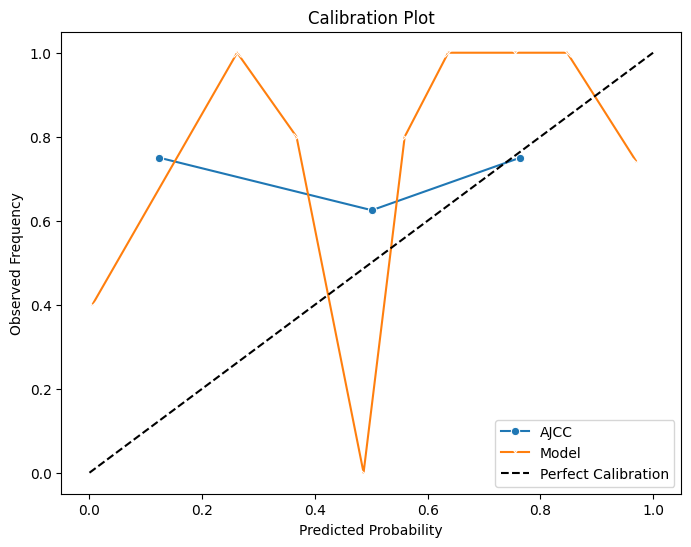

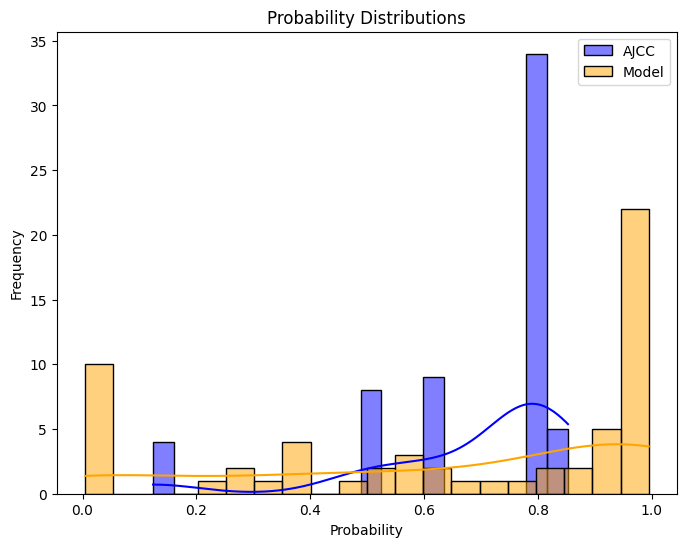

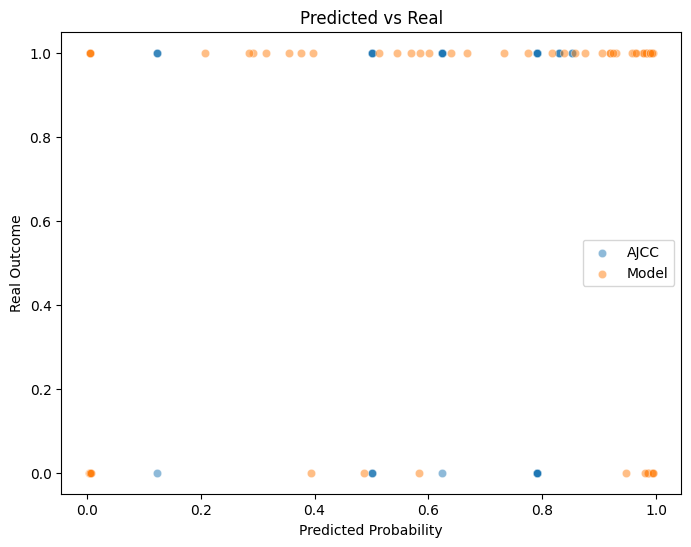

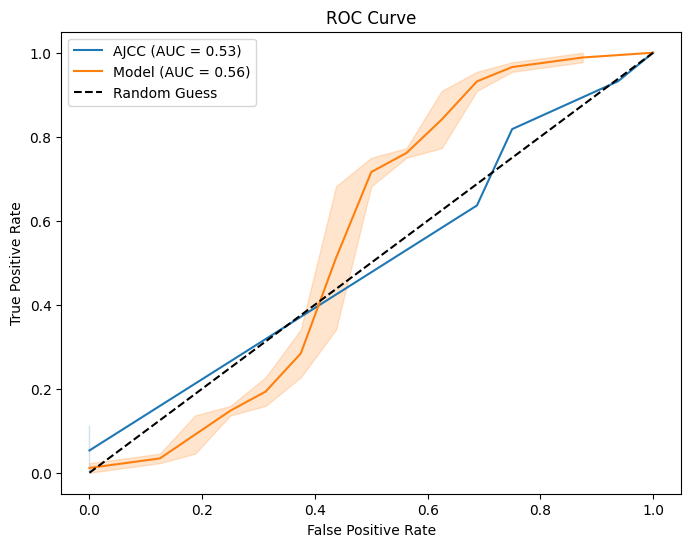

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss,
)

# Filter out rows where 'real_os_5_years' is 0.5
df_validation_filtered = df_validation[df_validation['real_os_5_years'] != 0.5].copy()

# Ensure probabilities are within the range [0, 1]
df_validation_filtered['staging_prob'] = df_validation_filtered['staging_prob'].clip(0, 1)
df_validation_filtered['os_5_years'] = df_validation_filtered['os_5_years'].clip(0, 1)

# Correlation Analysis
correlation_ajcc = df_validation_filtered['staging_prob'].corr(df_validation_filtered['real_os_5_years'])
correlation_model = df_validation_filtered['os_5_years'].corr(df_validation_filtered['real_os_5_years'])

print(f"Correlation (AJCC vs Real): {correlation_ajcc}")
print(f"Correlation (Model vs Real): {correlation_model}")

# Brier Score
brier_ajcc = brier_score_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_prob'])
brier_model = brier_score_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"Brier Score (AJCC): {brier_ajcc}")
print(f"Brier Score (Model): {brier_model}")

# AUROC Comparison
auroc_ajcc = roc_auc_score(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_prob'])
auroc_model = roc_auc_score(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"AUROC (AJCC): {auroc_ajcc}")
print(f"AUROC (Model): {auroc_model}")

# Logarithmic Loss
log_loss_ajcc = log_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_prob'])
log_loss_model = log_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"Log Loss (AJCC): {log_loss_ajcc}")
print(f"Log Loss (Model): {log_loss_model}")

# Calibration Plot
bins_ajcc = pd.cut(df_validation_filtered['staging_prob'], bins=3)
calibration_ajcc = df_validation_filtered.groupby(bins_ajcc)['real_os_5_years'].mean()
predicted_ajcc = df_validation_filtered.groupby(bins_ajcc)['staging_prob'].mean()

bins_model = pd.cut(df_validation_filtered['os_5_years'], bins=10)
calibration_model = df_validation_filtered.groupby(bins_model)['real_os_5_years'].mean()
predicted_model = df_validation_filtered.groupby(bins_model)['os_5_years'].mean()

plt.figure(figsize=(8, 6))
sns.lineplot(x=predicted_ajcc, y=calibration_ajcc, label='AJCC', marker='o')
sns.lineplot(x=predicted_model, y=calibration_model, label='Model', marker='x')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.legend()
plt.title('Calibration Plot')
plt.show()

# Probability Distributions
plt.figure(figsize=(8, 6))
sns.histplot(df_validation_filtered['staging_prob'], bins=20, kde=True, label='AJCC', color='blue', alpha=0.5)
sns.histplot(df_validation_filtered['os_5_years'], bins=20, kde=True, label='Model', color='orange', alpha=0.5)
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Probability Distributions')
plt.show()

# Predicted vs Real Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_validation_filtered['staging_prob'], y=df_validation_filtered['real_os_5_years'], label='AJCC', alpha=0.5)
sns.scatterplot(x=df_validation_filtered['os_5_years'], y=df_validation_filtered['real_os_5_years'], label='Model', alpha=0.5)
plt.xlabel('Predicted Probability')
plt.ylabel('Real Outcome')
plt.legend()
plt.title('Predicted vs Real')
plt.show()

# ROC Curve
fpr_ajcc, tpr_ajcc, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_prob'])
auc_ajcc = auc(fpr_ajcc, tpr_ajcc)

fpr_model, tpr_model, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])
auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_ajcc, y=tpr_ajcc, label=f'AJCC (AUC = {auc_ajcc:.2f})')
sns.lineplot(x=fpr_model, y=tpr_model, label=f'Model (AUC = {auc_model:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()





In [11]:
df_validation_filtered[[ 'staging_prob', 'os_5_years', 'real_os_5_years', 'os_3_years', 'staging']]

,staging_prob,os_5_years,real_os_5_years,os_3_years,staging
0,0.624,0.375455,1.0,0.751545,Stage IIIA
1,0.790,0.668308,1.0,0.890554,Stage II
2,0.790,0.314679,1.0,0.991083,Stage II
3,0.830,0.397893,1.0,0.746452,Stage IB
4,0.124,0.005520,1.0,0.077623,Stage IV
5,0.790,0.985401,1.0,0.998391,Stage II
6,0.790,0.993979,0.0,0.999269,Stage II
7,0.790,0.985171,0.0,0.999335,Stage II
8,0.790,0.979057,1.0,0.998221,Stage II
9,0.624,0.983637,1.0,0.998319,Stage IIIA


Model Brier Score: 0.2712 (95% CI: 0.1793 - 0.3651)
AJCC Brier Score: 0.2317 (95% CI: 0.1715 - 0.2927)


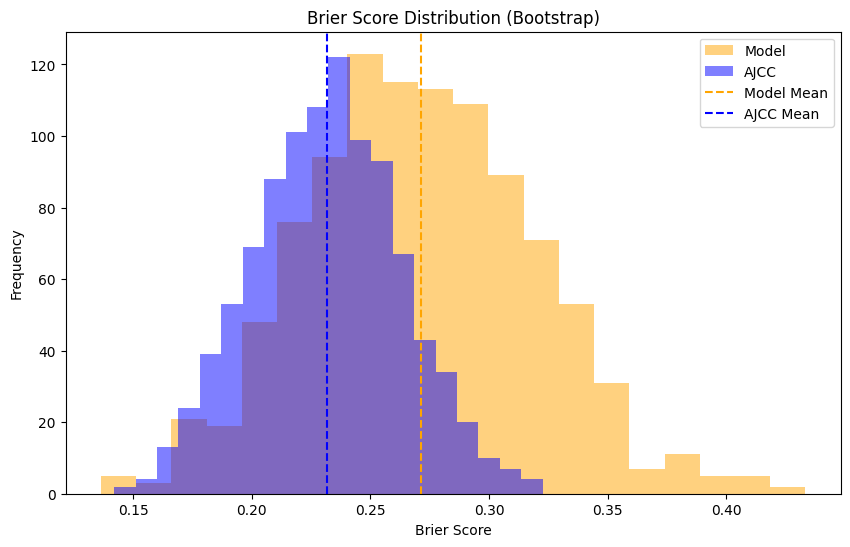

In [12]:
from sklearn.utils import resample
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Number of bootstrap samples
n_bootstraps = 1000

# Store Brier scores
brier_scores_model = []
brier_scores_ajcc = []

# Bootstrap loop
for _ in range(n_bootstraps):
    # Resample the filtered validation dataset
    boot = resample(df_validation_filtered)
    
    # Brier score for the model (os_5_years)
    brier_model = np.mean((boot['os_5_years'] - boot['real_os_5_years'])**2)
    brier_scores_model.append(brier_model)
    
    # Brier score for AJCC (staging_prob)
    brier_ajcc = np.mean((boot['staging_prob'] - boot['real_os_5_years'])**2)
    brier_scores_ajcc.append(brier_ajcc)

# Compute mean Brier scores
mean_brier_model = np.mean(brier_scores_model)
mean_brier_ajcc = np.mean(brier_scores_ajcc)

# Compute 95% confidence intervals
ci_brier_model = np.percentile(brier_scores_model, [2.5, 97.5])
ci_brier_ajcc = np.percentile(brier_scores_ajcc, [2.5, 97.5])

# Print results
print(f"Model Brier Score: {mean_brier_model:.4f} (95% CI: {ci_brier_model[0]:.4f} - {ci_brier_model[1]:.4f})")
print(f"AJCC Brier Score: {mean_brier_ajcc:.4f} (95% CI: {ci_brier_ajcc[0]:.4f} - {ci_brier_ajcc[1]:.4f})")

# Plot distributions
plt.figure(figsize=(10, 6))
plt.hist(brier_scores_model, bins=20, alpha=0.5, label='Model', color='orange')
plt.hist(brier_scores_ajcc, bins=20, alpha=0.5, label='AJCC', color='blue')
plt.axvline(mean_brier_model, color='orange', linestyle='--', label='Model Mean')
plt.axvline(mean_brier_ajcc, color='blue', linestyle='--', label='AJCC Mean')

# Add labels and legend
plt.xlabel('Brier Score')
plt.ylabel('Frequency')
plt.title('Brier Score Distribution (Bootstrap)')
plt.legend()
plt.show()


In [13]:
df_validation['staging'].value_counts()

staging
Stage II      51
Stage IIIA    20
Stage IIIB    15
Stage IV       8
Stage IB       7
Stage IA       3
Name: count, dtype: int64

Model AUC: 0.5626 (95% CI: 0.3557 - 0.7640)
AJCC AUC: 0.5284 (95% CI: 0.3862 - 0.6720)


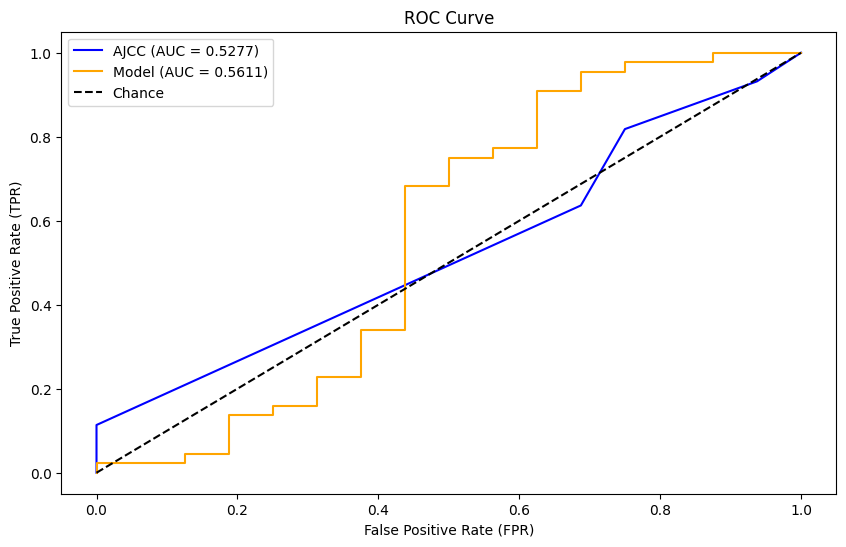

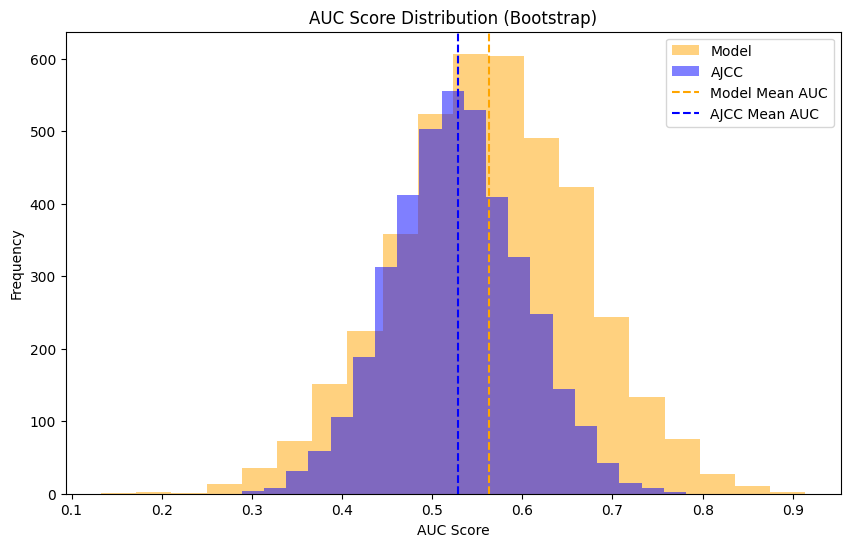

In [14]:
from sklearn.utils import resample
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# Number of bootstrap samples
n_bootstraps = 4000

# Store AUC scores
auc_scores_model = []
auc_scores_ajcc = []

# Bootstrap loop
for _ in range(n_bootstraps):
    # Resample the filtered validation dataset
    boot = resample(df_validation_filtered)
    
    # ROC and AUC for AJCC
    fpr_ajcc, tpr_ajcc, _ = roc_curve(boot['real_os_5_years'], boot['staging_prob'])
    auc_ajcc = auc(fpr_ajcc, tpr_ajcc)
    auc_scores_ajcc.append(auc_ajcc)
    
    # ROC and AUC for the model
    fpr_model, tpr_model, _ = roc_curve(boot['real_os_5_years'], boot['os_5_years'])
    auc_model = auc(fpr_model, tpr_model)
    auc_scores_model.append(auc_model)

# Compute mean AUC scores
mean_auc_model = np.mean(auc_scores_model)
mean_auc_ajcc = np.mean(auc_scores_ajcc)

# Compute 95% confidence intervals
ci_auc_model = np.percentile(auc_scores_model, [2.5, 97.5])
ci_auc_ajcc = np.percentile(auc_scores_ajcc, [2.5, 97.5])

# Print results
print(f"Model AUC: {mean_auc_model:.4f} (95% CI: {ci_auc_model[0]:.4f} - {ci_auc_model[1]:.4f})")
print(f"AJCC AUC: {mean_auc_ajcc:.4f} (95% CI: {ci_auc_ajcc[0]:.4f} - {ci_auc_ajcc[1]:.4f})")

# Plot the original ROC curves for reference
fpr_ajcc, tpr_ajcc, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_prob'])
fpr_model, tpr_model, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

plt.figure(figsize=(10, 6))

# AJCC ROC curve
plt.plot(fpr_ajcc, tpr_ajcc, label=f'AJCC (AUC = {auc(fpr_ajcc, tpr_ajcc):.4f})', color='blue')

# Model ROC curve
plt.plot(fpr_model, tpr_model, label=f'Model (AUC = {auc(fpr_model, tpr_model):.4f})', color='orange')

# Plot the diagonal line for reference
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Chance')

# Add labels and legend
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.legend()
plt.show()

# Plot AUC distributions
plt.figure(figsize=(10, 6))
plt.hist(auc_scores_model, bins=20, alpha=0.5, label='Model', color='orange')
plt.hist(auc_scores_ajcc, bins=20, alpha=0.5, label='AJCC', color='blue')
plt.axvline(mean_auc_model, color='orange', linestyle='--', label='Model Mean AUC')
plt.axvline(mean_auc_ajcc, color='blue', linestyle='--', label='AJCC Mean AUC')

# Add labels and legend
plt.xlabel('AUC Score')
plt.ylabel('Frequency')
plt.title('AUC Score Distribution (Bootstrap)')
plt.legend()
plt.show()

In [15]:
def confusion_df_validation(df_validation):
    conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
    accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
    print(f'Accuracy: {accuracy:.2f}')
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
    plt.show()
confusion_df_validation(df_validation)

KeyError: 'real_labels'

In [ ]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(config['model_config'])
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

def ROC_plot(generator, data_loader_val, condition):
    num_samples = 100  
    device = torch.device("cpu")  

    # Run aggregated inference
    pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

    # Aggregate probabilities (median)
    pred_probs_median = np.median(pred_probs_samples, axis=0)
    pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)


    probs_treatments = pred_probs_median[condition].copy()
    # Brier Score
    brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

    # Log Loss
    log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

    # AUC-ROC Score
    auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

    # Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
    gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

    # Precision, Recall, F1 Score
    precision_gan = precision_score(real_labels, gan_predictions)
    recall_gan = recall_score(real_labels, gan_predictions)
    f1_gan = f1_score(real_labels, gan_predictions)

    # Accuracy
    accuracy_gan = accuracy_score(real_labels, gan_predictions)

    # Print metrics
    print("Brier Score - GAN (Median):", brier_gan)
    print("Log Loss - GAN (Median):", log_loss_gan)
    print("AUC-ROC - GAN (Median):", auc_roc_gan)
    print("Precision - GAN (Median):", precision_gan)
    print("Recall - GAN (Median):", recall_gan)
    print("F1 Score - GAN (Median):", f1_gan)
    print("Accuracy - GAN (Median):", accuracy_gan)

    # Plot ROC Curve
    fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
    roc_auc_gan = auc(fpr_gan, tpr_gan)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    plt.title('ROC Curve - GAN (Median Aggregation)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return probs_treatments

probs_treatments =ROC_plot(generator, data_loader_val, condition)

no treatments

In [ ]:

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val =funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM)

df_validation  = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)



# def get_probs_treatments(generator, data_loader_val, condition):
#     def aggregate_inference(generator, data_loader, num_samples, device):
#         pred_probs = []
#         for _ in range(num_samples):
#             noise_function = get_noise_function(mc)
#             # Generate predictions with new noise each time
#             pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
#             pred_probs.append(pred_prob)
#         return np.array(pred_probs), real_labels

#     # Simulated inputs (replace these with real outputs)
#     num_samples = 100  # Number of runs per data point with different noise
#     device = torch.device("cpu")  # Simulated GAN predictions

#     # Run aggregated inference
#     pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

#     # Aggregate probabilities (median)
#     pred_probs_median = np.median(pred_probs_samples, axis=0)
#     pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)


#     probs_no_treatments = pred_probs_median[condition].copy()
#     # Brier Score
#     brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

#     # Log Loss
#     log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

#     # AUC-ROC Score
#     auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

#     # Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
#     gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

#     # Precision, Recall, F1 Score
#     precision_gan = precision_score(real_labels, gan_predictions)
#     recall_gan = recall_score(real_labels, gan_predictions)
#     f1_gan = f1_score(real_labels, gan_predictions)

#     # Accuracy
#     accuracy_gan = accuracy_score(real_labels, gan_predictions)

#     # Print metrics
#     print("Brier Score - GAN (Median):", brier_gan)
#     print("Log Loss - GAN (Median):", log_loss_gan)
#     print("AUC-ROC - GAN (Median):", auc_roc_gan)
#     print("Precision - GAN (Median):", precision_gan)
#     print("Recall - GAN (Median):", recall_gan)
#     print("F1 Score - GAN (Median):", f1_gan)
#     print("Accuracy - GAN (Median):", accuracy_gan)

#     # Plot ROC Curve
#     fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
#     roc_auc_gan = auc(fpr_gan, tpr_gan)

#     plt.figure(figsize=(8, 6))
#     plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
#     plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
#     plt.title('ROC Curve - GAN (Median Aggregation)')
#     plt.xlabel('False Positive Rate (FPR)')
#     plt.ylabel('True Positive Rate (TPR)')
#     plt.legend(loc='lower right')
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     return probs_no_treatments

probs_no_treatments = ROC_plot(generator, data_loader_val, condition)

surgery treatment

In [ ]:
def inference_function_treatments(df, df_val, data_loader_val, config):
    dc = config['data_config']
    sgc = config['simplegan_config']
    exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
    df = df.drop(columns=exclude)
    df = df.drop(columns=dc['labels'])
    sgc['input_dim'] = df.shape[1]
    mc = config['model_config']

    # Load the generator model and optimizer

    generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

    device = torch.device('cpu')
    optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
    generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)

    torch.manual_seed(43)
    noise_function = get_noise_function(mc)
    categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
    all_features = df.columns.tolist()
    numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
    pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
    return pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val

def preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2):
    config = MongoExtractor.load_config(config_file)

    # Extract data configuration
    dc = config['data_config']

    # Load training data
    mongo_extractor_train = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=config_file
    )
    df = mongo_extractor_train.get_dataframe()

    # Load validation data
    mongo_extractor_val = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=validation_data_config
    )
    df_val= mongo_extractor_val.get_dataframe()
    df_val_original = mongo_extractor_val.get_dataframe()

    dc = config['data_config']
    mc = config['model_config']
    sgc = config['simplegan_config']
    mc['latent_dim'] = 12
    mc['noise_type'] = 'uniform'
    mc['batch_size'] = 104



    df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)


    df[columns_to_zero] = 0
    df_val[columns_to_zero] = 0
    df_val_original[columns_to_zero] = 0

    df[columns_to_one] = 1
    df_val[columns_to_one] = 1
    df_val_original[columns_to_one] = 1



    df[columns_to_value] = value
    df_val[columns_to_value] = value
    df_val_original[columns_to_value] = value


    dataset_train = EHRDataset(df)
    dataset_val = EHRDataset(df_val)

    collate_fn_dc = partial(collate_fn, dc=dc)
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)

    return df, df_val, data_loader_val

In [ ]:
# SURGERY



columns_to_zero = [
        'treatment_features.chemotherapy', 
        
        'treatment_features.radiation_oncology', 
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        
        'treatment_features.dose',
        'treatment_features.chemotherapy',
                 'treatment_features.substances_nan', 
                 'treatment_features.cycle_number']

columns_to_one =['treatment_features.surgery',
                 ] 

columns_to_value =[
                 ] 


df, df_val, data_loader_val = preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2)

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val =inference_function_treatments(df, df_val, data_loader_val, config)

# Convert Tensors to DataFrame

df_validation = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)



probs_surgery_treatments = ROC_plot(generator, data_loader_val, condition)

In [ ]:
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:,1]

# Plot KDE for "yes_disease" with and without treatment
plt.figure(figsize=(8, 6))
sns.kdeplot(yes_disease_no_treatment, shade=True, label='Without Treatment', bw_adjust=1.0)
sns.kdeplot(yes_disease_treatment, shade=True, label='With Treatment', bw_adjust=1.0)
sns.kdeplot(yes_disease_surgery_treatments, shade=True, label='Surgery Treatment', bw_adjust=1.0)



# Customize the plot
plt.title('Probability Distribution of Yes_Disease')
plt.xlabel('Probability of Yes_Disease')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

radiation oncology

In [ ]:
columns_to_zero = [
        'treatment_features.chemotherapy', 
        
    
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        'treatment_features.chemotherapy',
                 'treatment_features.substances_nan'
        ]

columns_to_one =['treatment_features.radiation_oncology'
                 ] 


columns_to_value =['treatment_features.dose',
                 ] 

df, df_val, data_loader_val=preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2)

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val = inference_function_treatments(df, df_val, data_loader_val, config)
# Convert Tensors to DataFrame

df_validation = get_validation_df( pred_labels, real_labels, features, pred_prob, scaler)

probs_radiology_treatments = ROC_plot(generator, data_loader_val, condition)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data for different treatments
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:, 1]
yes_disease_radiology_treatments = probs_radiology_treatments[:, 1]

# Define the figure with 4 rows and 1 column
fig, axes = plt.subplots(4, 1, figsize=(8, 20), sharex=True)

# Define bin edges for consistent binning across all histograms
bins =10

# Plot individual histograms on separate subplots
axes[0].hist(yes_disease_no_treatment, bins=bins, alpha=0.5, color='blue', edgecolor='black')
axes[0].set_title('Probability Distribution - Without Treatment')
axes[0].set_ylabel('Density')
axes[0].grid(alpha=0.3)

axes[1].hist(yes_disease_treatment, bins=bins,  alpha=0.5, color='orange', edgecolor='black')
axes[1].set_title('Probability Distribution - With Treatment')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)

axes[2].hist(yes_disease_surgery_treatments, bins=bins, alpha=0.5, color='green', edgecolor='black')
axes[2].set_title('Probability Distribution - Surgery Treatment')
axes[2].set_ylabel('Density')
axes[2].grid(alpha=0.3)

axes[3].hist(yes_disease_radiology_treatments, bins=bins, alpha=0.5, color='red', edgecolor='black')
axes[3].set_title('Probability Distribution - Radiotherapy Treatment')
axes[3].set_xlabel('Long-term Disease Probability')
axes[3].set_ylabel('Distribution')
axes[3].grid(alpha=0.3)

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


chemotherapy

In [ ]:
columns_to_zero = [
        'treatment_features.chemotherapy', 
        
        'treatment_features.radiation_oncology', 
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        
        'treatment_features.dose',]

columns_to_one =['treatment_features.cycle_number'
                 ] 


columns_to_value =['treatment_features.chemotherapy',
                 'treatment_features.substances_nan'
                 ] 

df, df_val, data_loader_val=preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=0.5)



pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val = inference_function_treatments(df, df_val, data_loader_val, config)
# Convert Tensors to DataFrame

df_validation = get_validation_df( pred_labels, real_labels, features, pred_prob, scaler)

probs_chemotherapy_treatments = ROC_plot(generator, data_loader_val, condition)


In [ ]:
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:,1]
yes_disease_radiology_treatments= probs_radiology_treatments[:,1]
yes_disease_chemotherapy_treatments =probs_chemotherapy_treatments[:,1]


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Adjust bandwidth and plot KDEs
sns.kdeplot(yes_disease_no_treatment, shade=True, label='No Treatment', bw_adjust=1.0, common_norm=False)
# sns.kdeplot(yes_disease_surgery_treatments, shade=True, label='Surgery', bw_adjust=0.8)
# sns.kdeplot(yes_disease_radiology_treatments, shade=True, label='Radiotherapy', bw_adjust=0.8)
# sns.kdeplot(yes_disease_chemotherapy_treatments, shade=True, label='Chemotherapy', bw_adjust=0.8)

# Set X-axis limit to reasonable values
plt.xlim([0, 1])  # Adjust the range as per your data to keep it reasonable
plt.xlabel('Long-term Disease Probability')
plt.ylabel('Density')
# plt.title('Density Plot of Treatments')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(yes_disease_treatment, bins=20, density=True, alpha=0.5, label='With Treatment')
plt.hist(yes_disease_surgery_treatments, bins=20, density=True, alpha=0.5, label='Surgery')
plt.hist(yes_disease_radiology_treatments, bins=20, density=True, alpha=0.5, label='Radiotherapy')
plt.hist(yes_disease_chemotherapy_treatments, bins=20, density=True, alpha=0.5, label='Chemotherapy')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Histogram with Density Normalization')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to normalize data to the range [0, 1]
def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Normalize the data for each treatment
yes_disease_no_treatment = normalize_data(probs_no_treatments[:, 1])
yes_disease_treatment = normalize_data(probs_treatments[:, 1])
yes_disease_surgery_treatments = normalize_data(probs_surgery_treatments[:, 1])
yes_disease_radiology_treatments = normalize_data(probs_radiology_treatments[:, 1])
yes_disease_chemotherapy_treatments = normalize_data(probs_chemotherapy_treatments[:, 1])

# Create a dictionary for the data and categories
data_dict = {
    'Pre-Treatment': yes_disease_no_treatment,
    'Surgery': yes_disease_surgery_treatments,
    'Radiotherapy': yes_disease_radiology_treatments,
    'Chemotherapy': yes_disease_chemotherapy_treatments
}

# Prepare data for a single seaborn plot
plot_data = pd.concat(
    [pd.DataFrame({'Value': values, 'Category': category}) for category, values in data_dict.items()]
)

# Set font sizes globally
plt.rc('axes', titlesize=18)    # Font size for titles
plt.rc('axes', labelsize=16)    # Font size for x and y labels
plt.rc('xtick', labelsize=14)   # Font size for x-axis ticks
plt.rc('ytick', labelsize=14)   # Font size for y-axis ticks
plt.rc('legend', fontsize=14)   # Font size for legend
plt.rc('font', size=12)         # General font size

# Create the violin plots horizontally
plt.figure(figsize=(16, 8))
sns.violinplot(x='Category', y='Value', data=plot_data, bw=0.5, scale='width', cut=0)

# Set plot title and axis labels
# plt.title('Probability Distribution by Treatment Type (Normalized to [0, 1])', fontsize=20)
plt.xlabel('Treatment Type', fontsize=18)
plt.ylabel('Risk Level', fontsize=18)
plt.ylim(0, 1)  # Ensure the y-axis is between 0 and 1
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()



In [ ]:
# Define the ranges for sensitivity analysis
dose_range = range(1, 5)  # Example range of dose values
fractions_range = range(1, 5)  # Example range for number of fractions

# DataFrame to store results
sensitivity_results = []

for dose in dose_range:
    
    # Update DataFrames with the current dose and fractions
    df['treatment_features.dose'] = dose
    df['treatment_features.number_fractions'] = dose
    df_val['treatment_features.dose'] = dose
    df_val['treatment_features.number_fractions'] = dose
    mc = config['model_config']
    # Update the datasets and dataloaders
    dataset_val = EHRDataset(df_val)
    collate_fn_dc = partial(collate_fn, dc=config['data_config'])
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)
    noise_function = get_noise_function(mc)
    device = torch.device('cpu')
    # Perform inference
    pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
    
    # Aggregate results
    for idx, prob in enumerate(pred_prob):
        result = {
            'dose': dose,
            'number_fractions': dose,
            'real_label': real_labels[idx],
            'predicted_label': pred_labels[idx],
            'probability_no_disease': prob[0],
            'probability_yes_disease': prob[1]
        }
        sensitivity_results.append(result)

# Convert results to a DataFrame for analysis
sensitivity_df = pd.DataFrame(sensitivity_results)

# Save or display results
sensitivity_df.to_csv("sensitivity_analysis_results.csv", index=False)
print(sensitivity_df.head())


In [ ]:
# Assuming `sensitivity_df` is already available in memory from the previous script
# Filter and organize data for plotting
sensitivity_df['dose'] = sensitivity_df['dose'].astype(int)
sensitivity_df['probability_yes_disease'] = sensitivity_df['probability_yes_disease'].astype(float)

# Create a violin plot for the predicted probability vs. dose levels
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="dose",
    y="probability_yes_disease",
    data=sensitivity_df,
    # palette="viridis",
    bw=0.5,
    # inner="quartile"
    scale="width"
)
# plt.title("Violin Plot of Predicted Probabilities by Dose Levels", fontsize=16)
plt.xlabel("Dose Levels", fontsize=14)
plt.ylabel('Long-term Disease Probability', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1) 
# Show the plot
plt.tight_layout()
plt.show()


In [ ]:
medians = {
    'Pre-Treatment': np.median(yes_disease_no_treatment),
    'Surgery': np.median(yes_disease_surgery_treatments),
    'Radiotherapy': np.median(yes_disease_radiology_treatments),
    'Chemotherapy': np.median(yes_disease_chemotherapy_treatments)
}

medians

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 2D dictionary for medians (fill in the values manually)
medians = {
    'Stage IB': {
        'Pre-Treatment': 0.21,  # Add the median value here
        'Surgery': 0.13,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.17       # Add the median value here
    },

    'Stage II': {
        'Pre-Treatment': 0.94,  # Add the median value here
        'Surgery': 0.34,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.95       # Add the median value here
    },
    'Stage IIIB': {
        'Pre-Treatment': 0.93,  # Add the median value here
        'Surgery': 0.13,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.61       # Add the median value here
    },
    'Stage IV': {
        'Pre-Treatment': 0.70,  # Add the median value here
        'Surgery': 0.96,           # Add the median value here
        'Radiotherapy': 0.02,      # Add the median value here
        'Chemotherapy': 0.93       # Add the median value here
    }
}

# Convert the dictionary into a DataFrame for the heatmap
heatmap_data = pd.DataFrame(medians).T  # Transpose to align stages (rows) and treatments (columns)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('')
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example simulated data (replace with your actual dataset)
data = {
    'Stage': ['Stage IA', 'Stage IA', 'Stage IB', 'Stage IB', 'Stage II', 'Stage II'],
    'Tumor Size': ['T1', 'T2', 'T1', 'T2', 'T3', 'T4'],
    'Metastasis': ['M0', 'M0', 'M1', 'M1', 'M0', 'M1'],
    'Grade': ['G1', 'G2', 'G1', 'G3', 'G2', 'G3'],
    'Treatment': ['Surgery', 'Radiotherapy', 'Chemotherapy', 'Without Treatment', 'Surgery', 'Radiotherapy'],
    'Risk Level': ['Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'High Risk', 'Low Risk'],
    'Count': [5.0, 10.5, 15.2, 20.3, 25.0, 30.8]  # Example float counts
}

# Convert data to a DataFrame
df = pd.DataFrame(data)

# Create a combined column for Treatment and Risk Level
df['Treatment_Risk'] = df['Treatment'] + ' (' + df['Risk Level'] + ')'

# Pivot the data for hierarchical heatmap
pivot_data = df.pivot_table(
    index=['Stage', 'Tumor Size', 'Metastasis', 'Grade'],  # Hierarchy for Y-axis
    columns='Treatment_Risk',  # Columns for Treatment and Risk Level
    values='Count',  # Values to populate cells
    fill_value=0
)

# Plot the hierarchical heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",  # Format numbers as floats with two decimal places
    cmap="coolwarm",
    cbar=True
)
plt.title('Patient Distribution by Stage, Tumor Size, Metastasis, Grade, and Treatment-Risk Level', fontsize=16)
plt.ylabel('Hierarchy: Stage > Tumor Size > Metastasis > Grade', fontsize=12)
plt.xlabel('Treatment and Risk Level', fontsize=12)
plt.tight_layout()
plt.show()




In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data (replace with your actual dataset)
data = {
    'Stage': ['Stage IA', 'Stage IA', 'Stage IB', 'Stage IB', 'Stage II', 'Stage II'],
    'Tumor Size': ['T1 (≤5 cm)', 'T2 (5-10 cm)', 'T1 (≤5 cm)', 'T2 (5-10 cm)', 'T3 (10-15 cm)', 'T4 (>15 cm)'],
    'Metastasis': ['M0 (No)', 'M0 (No)', 'M1 (Yes)', 'M1 (Yes)', 'M0 (No)', 'M1 (Yes)'],
    'Grade': ['G1 (Low)', 'G2 (Intermediate)', 'G1 (Low)', 'G3 (High)', 'G2 (Intermediate)', 'G3 (High)'],
    'Treatment': ['Surgery', 'Radiotherapy', 'Chemotherapy', 'Without Treatment', 'Surgery', 'Radiotherapy'],
    'Risk Level': ['Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'High Risk', 'Low Risk'],
    'Count': [5.0, 10.5, 15.2, 20.3, 25.0, 30.8]  # Example counts
}

# Convert data to a DataFrame
df = pd.DataFrame(data)

# Create a combined column for hierarchical indexing
df['Hierarchy'] = (
    df['Stage'] + ' > ' +
    df['Tumor Size'] + ' > ' +
    df['Metastasis'] + ' > ' +
    df['Grade']
)

# Create a combined column for Treatment and Risk Level
df['Treatment_Risk'] = df['Treatment'] + ' (' + df['Risk Level'] + ')'

# Pivot the data to organize counts hierarchically
pivot_data = df.pivot_table(
    index='Hierarchy',  # Hierarchical Y-axis
    columns='Treatment_Risk',  # Treatments with Risk Levels
    values='Count',  # Values for heatmap
    fill_value=0
)

# Split the hierarchical index back into individual components for better visualization
pivot_data.index = pivot_data.index.str.split(' > ', expand=True)
pivot_data.index.names = ['Stage', 'Tumor Size', 'Metastasis', 'Grade']

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",  # Format as floats
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5  # Add gridlines for clarity
)

# Add custom labels
plt.title('Patient Distribution by Hierarchical Categories and Treatments', fontsize=18, pad=20)
plt.ylabel('Hierarchical Categories', fontsize=14)
plt.xlabel('Treatment and Risk Levels', fontsize=14)

# Adjust layout for clarity
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px

# Using the same data as above
fig = px.treemap(
    df,
    path=['Stage', 'Tumor Size', 'Metastasis', 'Grade', 'Treatment', 'Risk Level'],  # Hierarchy levels
    values='Count',  # Size of each block
    color='Treatment',  # Color blocks by Treatment
    title="Patient Distribution Treemap",
    width=800,
    height=800
)

# Show the Treemap
fig.show()


In [ ]:
import plotly.graph_objects as go

# Define the nodes in the hierarchy
nodes = [
    'Stage IA', 'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Stage and Tumor Sizes
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis
    'Low Grade (G1)', 'High Grade (G3)',  # Grades
    'Surgery (Low Risk)', 'Radiotherapy (High Risk)'  # Treatments
]

# Define links between nodes
links = dict(
    source=[0, 0, 1, 1, 2, 2, 3, 4],  # Source node indices
    target=[1, 2, 3, 4, 5, 6, 7, 8],  # Target node indices
    value=[30, 20, 10, 15, 5, 10, 10, 15]  # Patient counts for each path
)

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(title_text="Hierarchical Decision Tree Representation (Sankey Diagram)", font_size=10)
fig.show()



In [ ]:
import plotly.graph_objects as go

# Define the nodes (stages, treatments, and risk categories)
nodes = [
    'Stage IA High Risk', 'Stage IA Low Risk',  # Initial risk categories for Stage IA
    'Surgery', 'Radiotherapy', 'Chemotherapy',  # Treatment nodes
    'Stage IB High Risk', 'Stage IB Low Risk',  # Risk categories after treatment for Stage IB
    'Stage II High Risk', 'Stage II Low Risk'   # Risk categories after treatment for Stage II
]

# Define the links (transitions between nodes)
links = dict(
    source=[
        0, 0,  # Stage IA High Risk transitions to treatments
        1, 1,  # Stage IA Low Risk transitions to treatments
        2, 2, 2,  # Surgery outcomes (to High/Low Risk for Stage IB and Stage II)
        3, 3, 3,  # Radiotherapy outcomes
        4, 4, 4   # Chemotherapy outcomes
    ],
    target=[
        2, 3,  # Stage IA High Risk -> Surgery, Radiotherapy
        2, 4,  # Stage IA Low Risk -> Surgery, Chemotherapy
        5, 6, 7,  # Surgery -> High/Low Risk (Stage IB/II)
        5, 6, 8,  # Radiotherapy -> High/Low Risk (Stage IB/II)
        7, 8, 6   # Chemotherapy -> High/Low Risk (Stage IB/II)
    ],
    value=[
        30, 20,  # Stage IA High Risk -> Surgery, Radiotherapy
        10, 15,  # Stage IA Low Risk -> Surgery, Chemotherapy
        20, 10, 5,  # Surgery -> Stage IB/II High/Low Risk
        15, 10, 5,  # Radiotherapy -> Stage IB/II High/Low Risk
        10, 15, 5   # Chemotherapy -> Stage IB/II High/Low Risk
    ]
)

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display the diagram
fig.update_layout(
    title_text="Patient Category Transitions by Treatment",
    font_size=12
)

fig.show()


In [ ]:
import plotly.graph_objects as go

# Nodes in the hierarchy
nodes = [
    'Stage IA', 
    'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Tumor size categories
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis categories
    'Low Grade (G1)', 'High Grade (G3)',  # Grade categories
    'High Risk', 'Low Risk'  # Risk levels
]

# Links between nodes (source → target) with patient counts
links = dict(
    source=[
        0, 0,  # Stage IA → Tumor Size (T1, T2)
        1, 1, 2, 2,  # Tumor Size → Metastasis (M0, M1)
        3, 3, 4, 4,  # Metastasis → Grade (G1, G3)
        5, 5, 6, 6   # Grade → Risk Level (High, Low)
    ],
    target=[
        1, 2,  # Stage IA → Tumor Size (T1, T2)
        3, 4, 3, 4,  # Tumor Size → Metastasis (M0, M1)
        5, 6, 5, 6,  # Metastasis → Grade (G1, G3)
        7, 8, 7, 8   # Grade → Risk Level (High, Low)
    ],
    value=[
        50, 30,  # Patients from Stage IA → Tumor Sizes
        40, 10, 20, 10,  # Tumor Sizes → Metastasis
        15, 25, 10, 20,  # Metastasis → Grade
        20, 20, 15, 25   # Grade → Risk Levels
    ]
)

# Create Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(
    title_text="Patient Flow: Stage IA → Risk Levels via Tumor Size, Metastasis, and Grade",
    font_size=12
)

fig.show()


In [ ]:
import plotly.graph_objects as go

# Nodes for the hierarchy (specific to "Surgery")
nodes = [
    'Stage IA',  # Stage
    'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Tumor Size
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis
    'Low Grade (G1)', 'High Grade (G3)',  # Histologic Grade
    'High Risk', 'Low Risk'  # Risk Levels
]

# Links for "Surgery" treatment
links = dict(
    source=[
        0, 0,  # Stage IA → Tumor Sizes
        1, 1, 2, 2,  # Tumor Size → Metastasis
        3, 3, 4, 4,  # Metastasis → Grade
        5, 5, 6, 6   # Grade → Risk Levels
    ],
    target=[
        1, 2,  # Stage IA → Tumor Sizes
        3, 4, 3, 4,  # Tumor Size → Metastasis
        5, 6, 5, 6,  # Metastasis → Grade
        7, 8, 7, 8   # Grade → Risk Levels
    ],
    value=[
        40, 20,  # Stage IA → Tumor Sizes
        30, 10, 15, 5,  # Tumor Sizes → Metastasis
        10, 15, 5, 10,  # Metastasis → Grade
        5, 15, 10, 20   # Grade → Risk Levels
    ]
)

# Create Sankey Diagram for "Surgery"
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(
    title_text="Patient Flow for Surgery: Stage → Tumor Size → Metastasis → Grade → Risk Level",
    font_size=12
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# Group data to count patients for each path in the hierarchy
sankey_data = df_validation.groupby(
    ['size_category', 'metastasis_stage', 'grading', 'real_labels', 'predicted_labels']
).size().reset_index(name='count')

# Prepare unique nodes for the Sankey diagram
nodes = list(set(
    sankey_data['size_category'].tolist() +
    sankey_data['metastasis_stage'].tolist() +
    sankey_data['grading'].tolist() +
    sankey_data['real_labels'].map({0: 'Low Risk', 1: 'High Risk'}).tolist() +
    sankey_data['predicted_labels'].map({0: 'Predicted Low Risk', 1: 'Predicted High Risk'}).tolist()
))
node_indices = {node: i for i, node in enumerate(nodes)}

# Initialize source, target, and value lists
sources = []
targets = []
values = []

# Populate links for the Sankey diagram
for _, row in sankey_data.iterrows():
    # Tumor Size → Metastasis Stage
    sources.append(node_indices[row['size_category']])
    targets.append(node_indices[row['metastasis_stage']])
    values.append(row['count'])

    # Metastasis Stage → Grading
    sources.append(node_indices[row['metastasis_stage']])
    targets.append(node_indices[row['grading']])
    values.append(row['count'])

    # Grading → Real Risk Level
    real_risk_label = 'High Risk' if row['real_labels'] == 1 else 'Low Risk'
    sources.append(node_indices[row['grading']])
    targets.append(node_indices[real_risk_label])
    values.append(row['count'])

    # Real Risk Level → Predicted Risk Level
    predicted_risk_label = 'Predicted High Risk' if row['predicted_labels'] == 1 else 'Predicted Low Risk'
    sources.append(node_indices[real_risk_label])
    targets.append(node_indices[predicted_risk_label])
    values.append(row['count'])

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
))

# Add title and display
fig.update_layout(
    title_text="Patient Flow: Tumor Size → Metastasis → Grade → Risk Levels",
    font_size=14
)

fig.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss,
)

# Filter out rows where 'real_os_5_years' is 0.5
df_validation_filtered = df_validation[df_validation['real_os_5_years'] != 0.5].copy()

# Ensure probabilities are within the range [0, 1]
df_validation_filtered['staging_off'] = df_validation_filtered['staging_off'].clip(0, 1)
df_validation_filtered['os_5_years'] = df_validation_filtered['os_5_years'].clip(0, 1)

# Correlation Analysis
correlation_ajcc = df_validation_filtered['staging_off'].corr(df_validation_filtered['real_os_5_years'])
correlation_model = df_validation_filtered['os_5_years'].corr(df_validation_filtered['real_os_5_years'])

print(f"Correlation (AJCC vs Real): {correlation_ajcc}")
print(f"Correlation (Model vs Real): {correlation_model}")

# Brier Score
brier_ajcc = brier_score_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_off'])
brier_model = brier_score_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"Brier Score (AJCC): {brier_ajcc}")
print(f"Brier Score (Model): {brier_model}")

# AUROC Comparison
auroc_ajcc = roc_auc_score(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_off'])
auroc_model = roc_auc_score(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"AUROC (AJCC): {auroc_ajcc}")
print(f"AUROC (Model): {auroc_model}")

# Logarithmic Loss
log_loss_ajcc = log_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_off'])
log_loss_model = log_loss(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])

print(f"Log Loss (AJCC): {log_loss_ajcc}")
print(f"Log Loss (Model): {log_loss_model}")

# Calibration Plot
bins_ajcc = pd.cut(df_validation_filtered['staging_off'], bins=10)
calibration_ajcc = df_validation_filtered.groupby(bins_ajcc)['real_os_5_years'].mean()
predicted_ajcc = df_validation_filtered.groupby(bins_ajcc)['staging_off'].mean()

bins_model = pd.cut(df_validation_filtered['os_5_years'], bins=10)
calibration_model = df_validation_filtered.groupby(bins_model)['real_os_5_years'].mean()
predicted_model = df_validation_filtered.groupby(bins_model)['os_5_years'].mean()

plt.figure(figsize=(8, 6))
sns.lineplot(x=predicted_ajcc, y=calibration_ajcc, label='AJCC', marker='o')
sns.lineplot(x=predicted_model, y=calibration_model, label='Model', marker='x')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfect Calibration')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Frequency')
plt.legend()
plt.title('Calibration Plot')
plt.show()

# Probability Distributions
plt.figure(figsize=(8, 6))
sns.histplot(df_validation_filtered['staging_off'], bins=20, kde=True, label='AJCC', color='blue', alpha=0.5)
sns.histplot(df_validation_filtered['os_5_years'], bins=20, kde=True, label='Model', color='orange', alpha=0.5)
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.legend()
plt.title('Probability Distributions')
plt.show()

# Predicted vs Real Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_validation_filtered['staging_off'], y=df_validation_filtered['real_os_5_years'], label='AJCC', alpha=0.5)
sns.scatterplot(x=df_validation_filtered['os_5_years'], y=df_validation_filtered['real_os_5_years'], label='Model', alpha=0.5)
plt.xlabel('Predicted Probability')
plt.ylabel('Real Outcome')
plt.legend()
plt.title('Predicted vs Real')
plt.show()

# ROC Curve
fpr_ajcc, tpr_ajcc, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['staging_off'])
auc_ajcc = auc(fpr_ajcc, tpr_ajcc)

fpr_model, tpr_model, _ = roc_curve(df_validation_filtered['real_os_5_years'], df_validation_filtered['os_5_years'])
auc_model = auc(fpr_model, tpr_model)

plt.figure(figsize=(8, 6))
sns.lineplot(x=fpr_ajcc, y=tpr_ajcc, label=f'AJCC (AUC = {auc_ajcc:.2f})')
sns.lineplot(x=fpr_model, y=tpr_model, label=f'Model (AUC = {auc_model:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


